# U-Net baseline — resultado parcial (estágio 10)

Treina uma U-Net compacta sobre o conjunto experimental disponível em `MyDrive/tcc/imagens`, seleciona o melhor checkpoint pela IoU de validação e gera métricas e figuras de teste. O objetivo desta etapa é validar o pipeline completo com um resultado parcial real antes da integração definitiva da U-Mamba.

## Bootstrap

Obtém a versão atual do código compartilhado diretamente do repositório oficial do TCC.

In [1]:
import importlib
import pathlib
import sys
import urllib.request

BOOTSTRAP_URL = "https://raw.githubusercontent.com/oguel/tcc-umamba/main/src/bootstrap.py"
pathlib.Path("bootstrap.py").write_bytes(urllib.request.urlopen(BOOTSTRAP_URL).read())
sys.path.insert(0, str(pathlib.Path.cwd()))

bootstrap = importlib.import_module("bootstrap")
importlib.reload(bootstrap)
workspace = bootstrap.bootstrap_workspace()
print(f"Workspace: {workspace}")


Mounted at /content/drive
Workspace: /content


## Imports, seed e dispositivo

Carrega as rotinas reutilizáveis, fixa a seed e seleciona GPU quando disponível.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader

from src import io
from src.config import get_config
from src.data.dataset import CoffeeSegmentationDataset
from src.losses import BCEDiceLoss
from src.models.unet import UNet
from src.trainer import fit_model, run_epoch
from src.utils import set_all_seeds

config = get_config()
set_all_seeds(int(config["reproducibility"]["seed"]))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Dispositivo: cpu


## Dataset e DataLoaders

Carrega os subconjuntos já separados pelo professor. O conjunto de treino recebe augmentations leves; validação e teste permanecem determinísticos.

In [3]:
storage_paths = io.resolve_storage_paths()
dataset_root = storage_paths["data_embrapa"]
image_size = int(config["data"]["patch_size"])

train_dataset = CoffeeSegmentationDataset(
    dataset_root / "Imagens_treino",
    dataset_root / "Mascaras_treino",
    image_size=image_size,
    augment=True,
)
val_dataset = CoffeeSegmentationDataset(
    dataset_root / "Imagens_validacao",
    dataset_root / "Mascaras_validacao",
    image_size=image_size,
)
test_dataset = CoffeeSegmentationDataset(
    dataset_root / "Imagens_teste",
    dataset_root / "Mascaras_teste",
    image_size=image_size,
)

batch_size = int(config["training"]["batch_size"])
pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin_memory)

print(f"Treino: {len(train_dataset)} | Validação: {len(val_dataset)} | Teste: {len(test_dataset)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Treino: 60 | Validação: 30 | Teste: 10


## Modelo, loss e otimizador

Inicializa a U-Net baseline com entrada RGB, BCE + Dice Loss e AdamW.

In [4]:
channels = tuple(int(value) for value in config["model"]["unet_channels"])
model = UNet(
    in_channels=int(config["model"]["input_channels_experimental"]),
    out_channels=int(config["model"]["output_channels"]),
    channels=channels,
).to(device)

criterion = BCEDiceLoss(
    bce_weight=float(config["loss"]["bce_weight"]),
    dice_weight=float(config["loss"]["dice_weight"]),
)
optimizer = AdamW(model.parameters(), lr=float(config["training"]["lr"]), weight_decay=1e-4)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Parâmetros treináveis: {parameter_count:,}")


Parâmetros treináveis: 1,927,009


## Treinamento parcial

Executa um número reduzido de épocas, suficiente para um resultado preliminar. O melhor checkpoint é escolhido pela IoU de validação.

In [5]:
epochs = int(config["training"].get("partial_epochs", 10))
checkpoint_path = storage_paths["models_unet"] / "best_unet_experimental.pt"

history = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    checkpoint_path=checkpoint_path,
)


Epoch 01/10 | train_loss=1.2857 | val_loss=1.2394 | val_iou=0.0298 | val_f1=0.0580 | 171.8s | VRAM=0.0 MB
Epoch 02/10 | train_loss=1.1637 | val_loss=1.1402 | val_iou=0.3993 | val_f1=0.5707 | 89.1s | VRAM=0.0 MB
Epoch 03/10 | train_loss=1.0813 | val_loss=1.0839 | val_iou=0.4296 | val_f1=0.6010 | 90.4s | VRAM=0.0 MB
Epoch 04/10 | train_loss=1.0163 | val_loss=1.0212 | val_iou=0.4745 | val_f1=0.6436 | 89.7s | VRAM=0.0 MB
Epoch 05/10 | train_loss=0.9958 | val_loss=0.9892 | val_iou=0.5158 | val_f1=0.6805 | 89.8s | VRAM=0.0 MB
Epoch 06/10 | train_loss=0.9455 | val_loss=0.9846 | val_iou=0.5231 | val_f1=0.6869 | 89.2s | VRAM=0.0 MB
Epoch 07/10 | train_loss=0.9095 | val_loss=0.9637 | val_iou=0.5189 | val_f1=0.6832 | 88.3s | VRAM=0.0 MB
Epoch 08/10 | train_loss=0.8746 | val_loss=0.9406 | val_iou=0.5544 | val_f1=0.7133 | 88.2s | VRAM=0.0 MB
Epoch 09/10 | train_loss=0.8861 | val_loss=0.9891 | val_iou=0.4969 | val_f1=0.6639 | 88.9s | VRAM=0.0 MB
Epoch 10/10 | train_loss=0.8616 | val_loss=0.9384 | va

## Curvas de treinamento

Salva loss, IoU, F1, tempo por época e pico de VRAM no Google Drive.

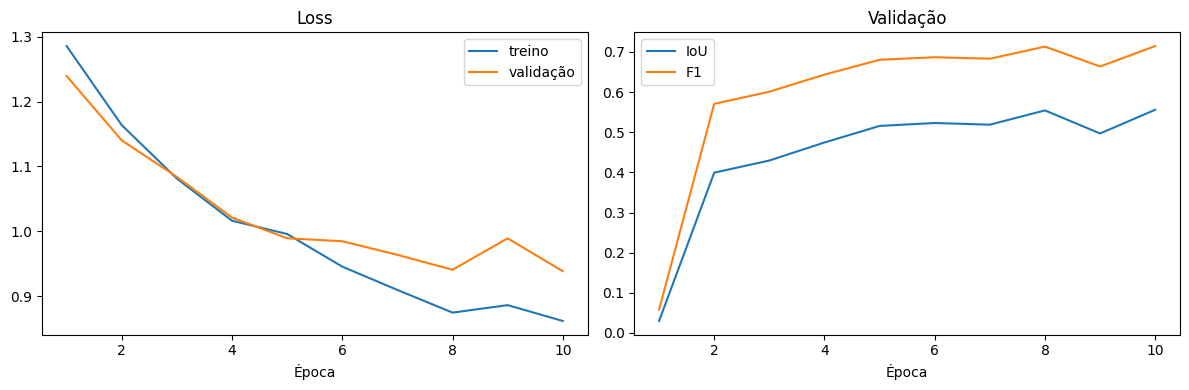

Histórico: /content/drive/MyDrive/tcc/artifacts/metrics/unet/experimental_history.csv
Curvas: /content/drive/MyDrive/tcc/artifacts/figures/unet/experimental_training_curves.png


In [6]:
history_df = pd.DataFrame(history)
metrics_dir = storage_paths["artifacts_metrics"] / "unet"
figures_dir = storage_paths["artifacts_figures"] / "unet"
metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

history_path = metrics_dir / "experimental_history.csv"
history_df.to_csv(history_path, index=False)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="treino")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validação")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["val_iou"], label="IoU")
axes[1].plot(history_df["epoch"], history_df["val_f1"], label="F1")
axes[1].set_title("Validação")
axes[1].set_xlabel("Época")
axes[1].legend()
figure.tight_layout()
curves_path = figures_dir / "experimental_training_curves.png"
figure.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Histórico: {history_path}")
print(f"Curvas: {curves_path}")


## Avaliação no teste

Restaura o melhor checkpoint e calcula as métricas agregadas no conjunto de teste.

In [7]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
test_metrics = run_epoch(model, test_loader, criterion, device)

test_metrics.update({
    "best_epoch": int(checkpoint["epoch"]),
    "best_val_iou": float(checkpoint["val_iou"]),
    "parameters": int(parameter_count),
})

metrics_path = metrics_dir / "experimental_test_metrics.json"
metrics_path.write_text(json.dumps(test_metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print(json.dumps(test_metrics, indent=2, ensure_ascii=False))
print(f"Métricas salvas em: {metrics_path}")


{
  "iou": 0.5535043014427291,
  "f1": 0.7125880513220252,
  "precision": 0.7385141497744957,
  "recall": 0.6884205274148542,
  "accuracy": 0.8165863037109375,
  "omission_error": 0.3115794725851459,
  "commission_error": 0.2614858502255043,
  "loss": 0.8851837396621705,
  "tp": 149010.0,
  "fp": 52760.0,
  "tn": 386148.0,
  "fn": 67442.0,
  "best_epoch": 10,
  "best_val_iou": 0.5560113806854075,
  "parameters": 1927009
}
Métricas salvas em: /content/drive/MyDrive/tcc/artifacts/metrics/unet/experimental_test_metrics.json


## Resultado visual

Gera a figura principal do resultado parcial: imagem original, ground truth e previsão binária.

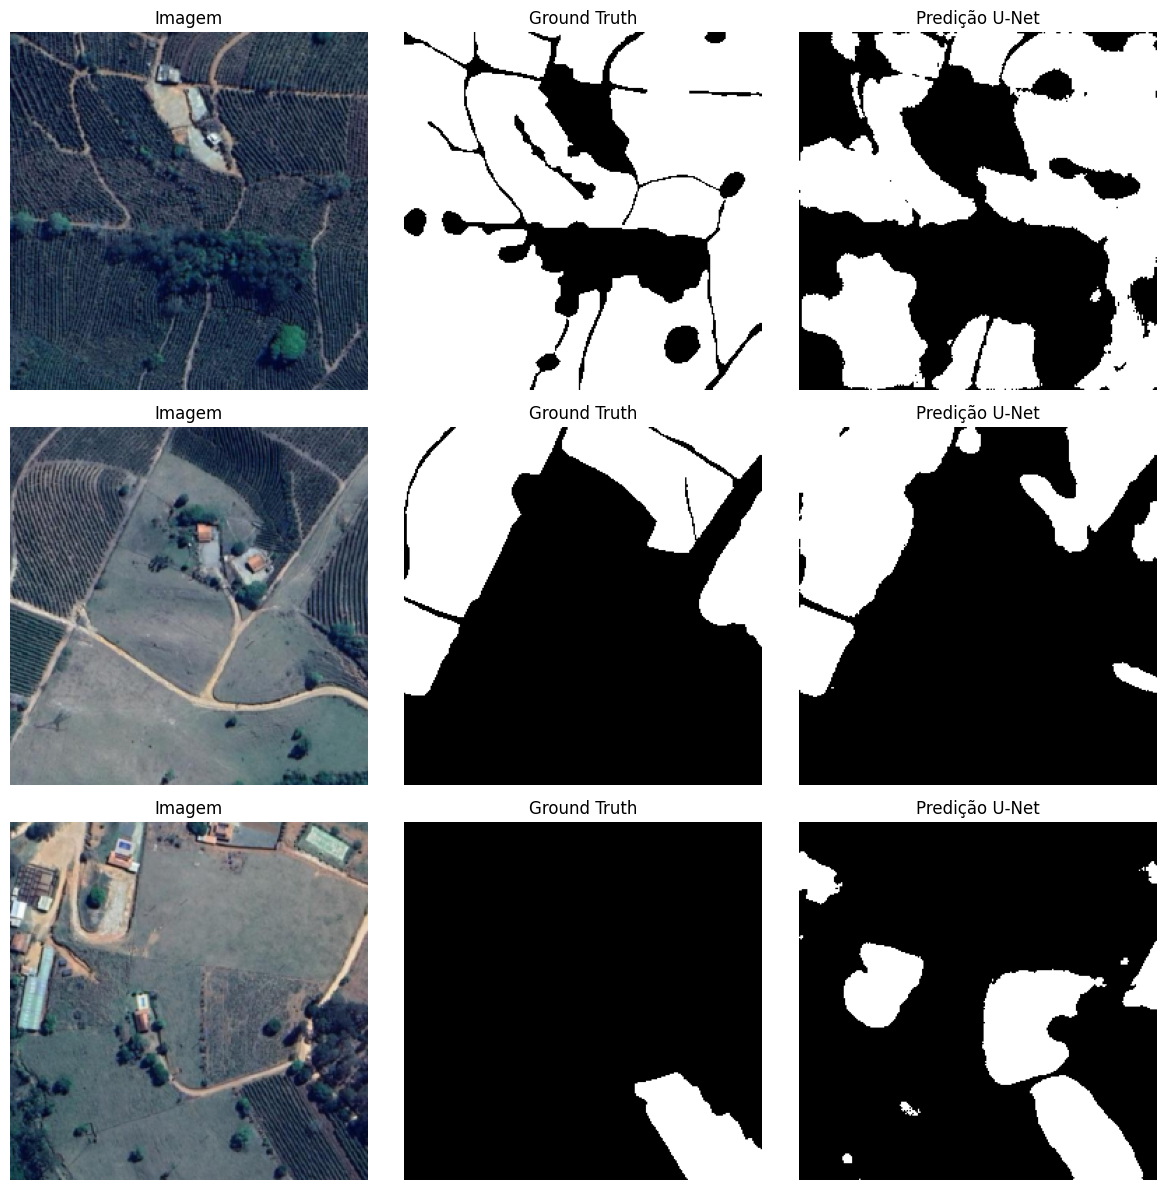

Resultado visual salvo em: /content/drive/MyDrive/tcc/artifacts/figures/unet/experimental_test_predictions.png


In [8]:
model.eval()
sample_count = min(3, len(test_dataset))
figure, axes = plt.subplots(sample_count, 3, figsize=(12, 4 * sample_count))
if sample_count == 1:
    axes = axes.reshape(1, -1)

with torch.inference_mode():
    for row in range(sample_count):
        image, mask = test_dataset[row]
        logits = model(image.unsqueeze(0).to(device))
        prediction = (torch.sigmoid(logits)[0, 0] >= 0.5).cpu().numpy()

        axes[row, 0].imshow(image.permute(1, 2, 0).numpy())
        axes[row, 0].set_title("Imagem")
        axes[row, 1].imshow(mask[0].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground Truth")
        axes[row, 2].imshow(prediction, cmap="gray", vmin=0, vmax=1)
        axes[row, 2].set_title("Predição U-Net")
        for col in range(3):
            axes[row, col].axis("off")

figure.tight_layout()
prediction_path = figures_dir / "experimental_test_predictions.png"
figure.savefig(prediction_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Resultado visual salvo em: {prediction_path}")


## Interpretação correta

Este experimento é preliminar. As métricas servem para provar que a cadeia de dados, treinamento, inferência e avaliação está funcional. Elas não devem ser tratadas como desempenho definitivo da U-Mamba nem como conclusão final do TCC.